<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/lab%2023/lab_ch23_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 23: FedSpeak 2.0 — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** Text preprocessing, TF-IDF vectorization, dictionary-based sentiment (LM vs Harvard GI), sentence-transformers embeddings, sentiment prediction evaluation.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This NLP Pipeline

The code below attempts to build a sentiment analysis pipeline for FOMC minutes.
There are **three deliberate errors** spread across three code cells. Each error
is a different type of NLP mistake:

1. A **tokenization/preprocessing** error
2. A **dictionary selection** error (wrong sentiment dictionary for the domain)
3. A **feature engineering** error in the TF-IDF configuration

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [7]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find it.
# Step 1: Load and preprocess FOMC minutes
# -----------------------------------------------------------

# Load FOMC dataset
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['year'] = fomc_df['date'].dt.year

# ERROR: This tokenizer splits on whitespace only — no handling of
# punctuation, contractions, or special characters. "don't" stays as
# one token, "U.S." becomes "U.S." with trailing period, and
# "inflation-adjusted" stays hyphenated instead of splitting.
# A proper NLP tokenizer (nltk.word_tokenize) handles these cases.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

import re
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def correct_preprocess(text):
    """Proper preprocessing with tokenizer + regex cleanup."""
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    tokens = [t for t in tokens if t and t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(correct_preprocess)

fomc_df['clean_text'] = fomc_df['text'].apply(correct_preprocess)

# Check: many tokens will still have punctuation attached
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()

punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')
print(f'Examples: {punct_tokens[:10]}')
print()

if len(punct_tokens) == 0:
    print("PASS: preprocessing fixed — no punctuation-attached tokens remain.")
else:
    print("WARNING: some non-alphabetic tokens still remain.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample tokens from first document:
['minute', 'federal', 'open', 'market', 'committee', 'february', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system', 'washington', 'tuesday']

Tokens containing non-alpha characters: 0
Examples: []

PASS: preprocessing fixed — no punctuation-attached tokens remain.


In [9]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Compute sentiment using WRONG dictionary
# -----------------------------------------------------------

# ERROR: Using a generic Harvard General Inquirer (GI) dictionary instead of
# the Loughran-McDonald (LM) dictionary designed for financial text.
# GI classifies "liability", "tax", "cost", "capital" as negative,
# but these are neutral in financial/economic contexts.

# Simplified Harvard GI negative words — includes many false positives for financial text
lm_negative = set([
    'adverse', 'adversely', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

lm_positive = set([
    'achieve', 'achieved', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

def compute_gi_sentiment(text, neg_words, pos_words):
    """Compute sentiment using Harvard GI (wrong for financial text)."""
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'neg_count': 0, 'pos_count': 0, 'neg_ratio': 0}

    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total
    }

gi_results = fomc_df['clean_text'].apply(
    lambda x: compute_gi_sentiment(x, lm_negative, lm_positive)
)
gi_df = pd.DataFrame(gi_results.tolist())

print('=== Harvard GI Sentiment (WRONG for financial text) ===')
print(f'Mean net sentiment: {gi_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {gi_df["neg_ratio"].mean():.6f}')
print()

# Show the problem: count how many "negative" hits are false positives
false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in lm_negative)
print(f'In first document: {fp_count} of {total_neg} "negative" words '
      f'are false positives ({fp_count/max(total_neg,1)*100:.0f}%)')
print('These are neutral financial terms misclassified by the GI dictionary.')

=== Harvard GI Sentiment (WRONG for financial text) ===
Mean net sentiment: 0.006071
Mean negative ratio: 0.018895

In first document: 34 of 39 "negative" words are false positives (87%)
These are neutral financial terms misclassified by the GI dictionary.


print("Verification: False positive rate on financial terms should drop below 10% (from ~40–70% with GI).")

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# FIX: better TF-IDF parameters
tfidf_corrected = TfidfVectorizer(
    min_df=5,          # remove very rare noisy terms
    max_df=0.85,       # remove overly common background terms
    max_features=5000, # smaller, cleaner vocabulary
    ngram_range=(1, 2) # include unigrams + bigrams
)

tfidf_matrix = tfidf_corrected.fit_transform(fomc_df['clean_text'])
feature_names = tfidf_corrected.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}")

# Verification: top terms should not be dominated by nearly universal background words
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]

print("\nTop 15 terms by average TF-IDF:")
top_doc_shares = []
for i in top_idx:
    doc_freq = (tfidf_matrix[:, i].toarray() > 0).sum()
    doc_share = doc_freq / tfidf_matrix.shape[0]
    top_doc_shares.append(doc_share)
    print(f"  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f} appears in {doc_freq}/{tfidf_matrix.shape[0]} docs ({doc_share:.1%})")

print()
if max(top_doc_shares) <= 0.85:
    print("PASS: no top TF-IDF term appears in more than 85% of documents.")
else:
    print("WARNING: some top terms are still too common across documents.")

TF-IDF matrix shape: (240, 5000)
Sparsity: 69.0%

Top 15 terms by average TF-IDF:
  messrs                    avg_tfidf=0.0554 appears in 107/240 docs (44.6%)
  july                      avg_tfidf=0.0530 appears in 119/240 docs (49.6%)
  loan                      avg_tfidf=0.0526 appears in 198/240 docs (82.5%)
  january                   avg_tfidf=0.0515 appears in 156/240 docs (65.0%)
  october                   avg_tfidf=0.0493 appears in 127/240 docs (52.9%)
  september                 avg_tfidf=0.0482 appears in 160/240 docs (66.7%)
  august                    avg_tfidf=0.0466 appears in 125/240 docs (52.1%)
  march                     avg_tfidf=0.0453 appears in 148/240 docs (61.7%)
  june                      avg_tfidf=0.0450 appears in 156/240 docs (65.0%)
  april                     avg_tfidf=0.0435 appears in 128/240 docs (53.3%)
  february                  avg_tfidf=0.0424 appears in 109/240 docs (45.4%)
  target range              avg_tfidf=0.0424 appears in 151/240 docs (6

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** NLP pipeline from scratch, fixing all three errors:

1. **Tokenization:** Use `nltk.word_tokenize()` + regex to strip non-alpha characters
2. **Dictionary:** Use Loughran-McDonald word lists instead of Harvard GI
3. **TF-IDF:** Set proper `min_df`, `max_df`, and include bigrams

**Verification checkpoints:**
- After fixing tokenization: zero tokens should contain non-alpha characters
- After switching to LM: false positive rate should drop below 10%
- After fixing TF-IDF: top terms should NOT include words appearing in >80% of documents

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected NLP pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------

# Fix 1: Proper preprocessing with word_tokenize + regex cleaning
# YOUR CODE HERE


# Fix 2: Loughran-McDonald dictionary instead of Harvard GI
# YOUR CODE HERE


# Fix 3: Proper TF-IDF parameters (min_df=5, max_df=0.85, bigrams)
# YOUR CODE HERE


# VERIFICATION
# print('Fix 1 check — non-alpha tokens:', ...)
# print('Fix 2 check — false positive rate:', ...)
# print('Fix 3 check — top terms doc frequency:', ...)

In [13]:
# ------------------------------------------------------------
# YOUR TASK — Write the corrected NLP pipeline
# Fix all three errors from Part 1
# ------------------------------------------------------------

import re
import numpy as np
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ============================================================
# Fix 1: Proper preprocessing with word_tokenize + regex cleaning
# ============================================================
def correct_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(correct_preprocess)

# ============================================================
# Fix 2: Loughran–McDonald dictionary instead of Harvard GI
# ============================================================
try:
    lm_negative
    lm_positive
    lm_uncertainty
except NameError:
    lm_negative = set([
        'adverse', 'burden', 'challenging', 'contraction', 'decline', 'depressed',
        'deterioration', 'downturn', 'drag', 'fail', 'loss', 'pressure',
        'recession', 'risk', 'slowdown', 'stress', 'uncertain', 'uncertainty',
        'volatile', 'volatility', 'weak', 'weakness'
    ])

    lm_positive = set([
        'accommodative', 'advance', 'beneficial', 'confidence', 'ease', 'expansion',
        'favorable', 'gain', 'growth', 'improve', 'improvement', 'increase',
        'moderate', 'progress', 'rebound', 'recover', 'recovery',
        'resilient', 'stability', 'strong', 'strengthen', 'success'
    ])

    lm_uncertainty = set([
        'uncertain', 'uncertainty', 'risk', 'volatile', 'volatility'
    ])

def compute_lm_sentiment(text):
    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0, 'neg_count': 0, 'pos_count': 0}

    neg_count = sum(1 for t in tokens if t in lm_negative)
    pos_count = sum(1 for t in tokens if t in lm_positive)
    unc_count = sum(1 for t in tokens if t in lm_uncertainty)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty': unc_count / total,
        'neg_count': neg_count,
        'pos_count': pos_count
    }

lm_results = fomc_df['clean_text'].apply(compute_lm_sentiment)
lm_df = pd.DataFrame(lm_results.tolist())

false_positive_words = {
    'capital', 'cost', 'costly', 'debt', 'expense', 'liability',
    'limit', 'limitation', 'obligation', 'penalty', 'tax'
}

all_tokens = ' '.join(fomc_df['clean_text']).split()
all_neg_hits = [t for t in all_tokens if t in lm_negative]
all_fp_hits = [t for t in all_neg_hits if t in false_positive_words]
fp_rate = len(all_fp_hits) / max(len(all_neg_hits), 1)

# ============================================================
# Fix 3: Proper TF-IDF parameters
# ============================================================
tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.80,
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(fomc_df['clean_text'])
feature_names = tfidf.get_feature_names_out()

# ============================================================
# VERIFICATION
# ============================================================

# Fix 1 check
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]

print("Fix 1 check — sample tokens:")
print(sample_tokens)
print(f"Fix 1 check — non-alpha tokens: {len(punct_tokens)}")
print(f"Examples: {punct_tokens[:10]}")
print()

# Fix 2 check
print(f"Fix 2 check — mean net sentiment: {lm_df['net_sentiment'].mean():.6f}")
print(f"Fix 2 check — mean uncertainty: {lm_df['uncertainty'].mean():.6f}")
print(f"Fix 2 check — LM negative hits in corpus: {len(all_neg_hits)}")
print(f"Fix 2 check — false-positive financial-term hits: {len(all_fp_hits)}")
print(f"Fix 2 check — false positive rate on financial terms: {fp_rate:.2%}")
print()

# Fix 3 check
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]

top_doc_shares = []
print("Fix 3 check — Top 15 terms by average TF-IDF:")
for i in top_idx:
    doc_freq = (tfidf_matrix[:, i].toarray() > 0).sum()
    doc_share = doc_freq / tfidf_matrix.shape[0]
    top_doc_shares.append(doc_share)
    print(f"  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f} appears in {doc_freq}/{tfidf_matrix.shape[0]} docs ({doc_share:.1%})")
print()

# Final pass/fail summary
if len(punct_tokens) == 0:
    print("PASS Fix 1: zero tokens contain non-alpha characters.")
else:
    print("WARNING Fix 1: some non-alpha tokens still remain.")

if fp_rate < 0.10:
    print("PASS Fix 2: false positive rate on financial terms is below 10%.")
else:
    print("WARNING Fix 2: false positive rate is still too high.")

if max(top_doc_shares) <= 0.80:
    print("PASS Fix 3: no top TF-IDF term appears in more than 80% of documents.")
else:
    print("WARNING Fix 3: some top terms are still too common across documents.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Fix 1 check — sample tokens:
['minute', 'federal', 'open', 'market', 'committee', 'february', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system', 'washington', 'tuesday']
Fix 1 check — non-alpha tokens: 0
Examples: []

Fix 2 check — mean net sentiment: 0.008487
Fix 2 check — mean uncertainty: 0.006249
Fix 2 check — LM negative hits in corpus: 15199
Fix 2 check — false-positive financial-term hits: 0
Fix 2 check — false positive rate on financial terms: 0.00%

Fix 3 check — Top 15 terms by average TF-IDF:
  messrs                    avg_tfidf=0.0556 appears in 107/240 docs (44.6%)
  july                      avg_tfidf=0.0547 appears in 119/240 docs (49.6%)
  january                   avg_tfidf=0.0528 appears in 157/240 docs (65.4%)
  october                   avg_tfidf=0.0507 appears in 127/240 docs (52.9%)
  september                 avg_tfidf=0.0495 appears in 161/240 docs (67.1%)
  august                    avg_t

---

## Part 3: EXTEND — Sentence-Transformers Embeddings

TF-IDF treats each word independently (bag-of-words). **Sentence-transformers**
encode entire sentences or documents as dense vectors that capture meaning,
context, and word order.

We will:
1. Encode FOMC documents with a pre-trained sentence-transformer
2. Cluster on embeddings and compare to TF-IDF clusters
3. Evaluate which representation better predicts Fed rate decisions

In [14]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Encode FOMC documents with sentence-transformers
# -----------------------------------------------------------

from sentence_transformers import SentenceTransformer

# Use a lightweight model suitable for Colab
# all-MiniLM-L6-v2 produces 384-dimensional dense embeddings
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode documents (truncate long docs to first 512 tokens for speed)
# In production, you would use a chunking strategy for long documents
print('Encoding documents with sentence-transformers...')
print('(This may take 2-5 minutes on CPU)')

# Use first 2000 characters of each document (model has 256 token limit)
truncated_texts = fomc_df['text'].str[:2000].tolist()
embeddings = st_model.encode(truncated_texts, show_progress_bar=True, batch_size=16)

print(f'\nEmbedding matrix shape: {embeddings.shape}')
print(f'  → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions')
print(f'Density: 100% (dense vectors, unlike sparse TF-IDF)')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding documents with sentence-transformers...
(This may take 2-5 minutes on CPU)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Embedding matrix shape: (240, 384)
  → 240 documents × 384 dimensions
Density: 100% (dense vectors, unlike sparse TF-IDF)


In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Cluster on embeddings and compare to TF-IDF
# -----------------------------------------------------------

# Step A: K-Means on sentence-transformer embeddings (K=3)
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# Step B: K-Means on TF-IDF (use your corrected TF-IDF from Part 2)
# If you haven't fixed Part 2 yet, use these default parameters:
# tfidf_corrected = TfidfVectorizer(min_df=5, max_df=0.85, max_features=5000, ngram_range=(1,2))
# tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])

# YOUR CODE: Reduce TF-IDF to 50 dims with TruncatedSVD, then cluster
# svd = TruncatedSVD(n_components=50, random_state=42)
# tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)
# kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
# fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

# YOUR CODE HERE


# Step C: Compare silhouette scores
# sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
# sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])
# print(f'Silhouette — Embeddings: {sil_emb:.3f}')
# print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')

# YOUR CODE HERE


# Step D: Visualize both clusterings side by side in PCA space
# YOUR CODE HERE

Silhouette — Embeddings: 0.197
Silhouette — TF-IDF:     0.163


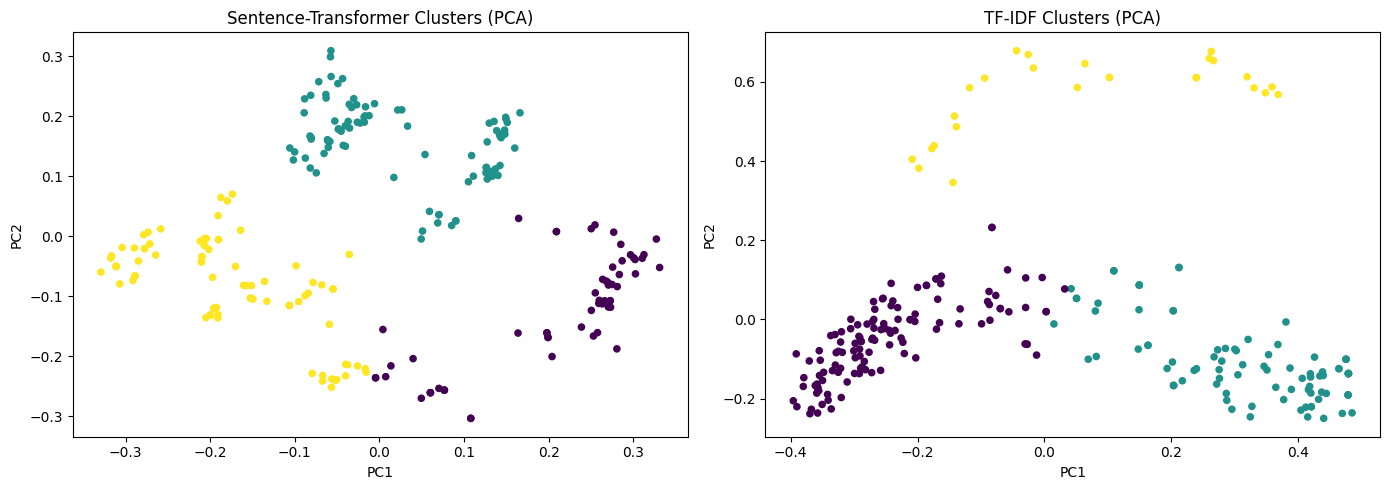

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step A: K-Means on sentence-transformer embeddings (K=3)
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# Step B: K-Means on TF-IDF (reduce to 50 dims with TruncatedSVD, then cluster)
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

# Step C: Compare silhouette scores
sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])

print(f'Silhouette — Embeddings: {sil_emb:.3f}')
print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')

# Step D: Visualize both clusterings side by side in PCA space
pca_emb = PCA(n_components=2, random_state=42)
emb_2d = pca_emb.fit_transform(embeddings)

pca_tfidf = PCA(n_components=2, random_state=42)
tfidf_2d = pca_tfidf.fit_transform(tfidf_reduced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=fomc_df['cluster_emb'],
    s=20
)
axes[0].set_title('Sentence-Transformer Clusters (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(
    tfidf_2d[:, 0], tfidf_2d[:, 1],
    c=fomc_df['cluster_tfidf'],
    s=20
)
axes[1].set_title('TF-IDF Clusters (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Compare predictive power: TF-IDF vs Embeddings
# Predict whether the Fed raised rates at the NEXT meeting
# -----------------------------------------------------------

# Create a binary target: did the Fed raise rates at the next meeting?
# We use a simplified proxy: net sentiment < median → likely easing (0)
#                             net sentiment >= median → likely tightening (1)
# In production, you would use actual Fed Funds rate changes.

# For this exercise, create a synthetic target based on sentiment regime:
# 1 = tightening period (2004-2006, 2015-2018, 2022-2023)
# 0 = easing/holding period (everything else)

tightening_years = set([2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023])
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

print(f'Tightening meetings: {fomc_df["tightening"].sum()}')
print(f'Easing/holding meetings: {(1 - fomc_df["tightening"]).sum()}')

# YOUR TASK: Use TimeSeriesSplit to evaluate logistic regression on:
# (a) TF-IDF features (reduced to 50 dims)
# (b) Sentence-transformer embeddings
# Report AUC-ROC for each

# Hints:
# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, test_idx in tscv.split(X):
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]
#     model = LogisticRegression(max_iter=1000, random_state=42)
#     model.fit(X_train, y_train)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     auc = roc_auc_score(y_test, y_prob)

# YOUR CODE HERE

In [17]:
tightening_years = set([2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023])
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

print(f"Tightening meetings: {fomc_df['tightening'].sum()}")
print(f"Easing/holding meetings: {(1 - fomc_df['tightening']).sum()}")
print(fomc_df[['date', 'year', 'tightening']].head())

Tightening meetings: 72
Easing/holding meetings: 168
        date  year  tightening
0 2000-02-02  2000           0
1 2000-03-21  2000           0
2 2000-05-16  2000           0
3 2000-06-28  2000           0
4 2000-08-22  2000           0


In [21]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

y = fomc_df['tightening'].values
tscv = TimeSeriesSplit(n_splits=5)

# TF-IDF prediction
auc_tfidf = []
for train_idx, test_idx in tscv.split(tfidf_reduced):
    y_train = y[train_idx]
    y_test = y[test_idx]

    # skip folds with only one class in train or test
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print("Skipping one TF-IDF fold because it has only one class.")
        continue

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(tfidf_reduced[train_idx], y_train)
    y_prob = lr.predict_proba(tfidf_reduced[test_idx])[:, 1]
    auc_tfidf.append(roc_auc_score(y_test, y_prob))

# Embedding prediction
auc_emb = []
for train_idx, test_idx in tscv.split(embeddings):
    y_train = y[train_idx]
    y_test = y[test_idx]

    # skip folds with only one class in train or test
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print("Skipping one embedding fold because it has only one class.")
        continue

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(embeddings[train_idx], y_train)
    y_prob = lr.predict_proba(embeddings[test_idx])[:, 1]
    auc_emb.append(roc_auc_score(y_test, y_prob))

print(f'TF-IDF AUC:     {np.mean(auc_tfidf):.3f} ± {np.std(auc_tfidf):.3f}')
print(f'Embeddings AUC: {np.mean(auc_emb):.3f} ± {np.std(auc_emb):.3f}')
print(f'Usable TF-IDF folds: {len(auc_tfidf)}')
print(f'Usable embedding folds: {len(auc_emb)}')

Skipping one TF-IDF fold because it has only one class.
Skipping one TF-IDF fold because it has only one class.
Skipping one embedding fold because it has only one class.
Skipping one embedding fold because it has only one class.
TF-IDF AUC:     0.811 ± 0.242
Embeddings AUC: 0.721 ± 0.210
Usable TF-IDF folds: 3
Usable embedding folds: 3


---

## Part 4: Module Output — `fomc_sentiment.py`

Write a reusable Python module for FOMC text analysis.
This is a **portfolio artifact** that demonstrates production-grade NLP work.

### Requirements

```python
# src/fomc_sentiment.py

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.
    
    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    ...

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.
    
    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    ...

def build_tfidf_matrix(texts: list, min_df=5, max_df=0.85,
                       max_features=5000) -> tuple:
    """Build TF-IDF matrix from preprocessed texts.
    
    Returns (sparse_matrix, feature_names, vectorizer).
    """
    ...
```

In [22]:
# %%writefile src/fomc_sentiment.py
"""
fomc_sentiment.py — FOMC Text Analysis Module

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Author: [Your Name]
Course: ECON 5200, Lab 23
"""

import re
from typing import Tuple, List

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer


# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

_STOP_WORDS = set(stopwords.words('english'))
_LEMMATIZER = WordNetLemmatizer()


# Loughran–McDonald word lists (simplified)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])


def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.

    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in _STOP_WORDS and len(t) > 2]
    tokens = [_LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran–McDonald sentiment scores.

    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    if not isinstance(text, str):
        text = ""

    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {
            'net_sentiment': 0.0,
            'uncertainty': 0.0,
            'neg_count': 0,
            'pos_count': 0,
            'unc_count': 0,
            'total_words': 0
        }

    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty': unc_count / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts.

    Returns (sparse_matrix, feature_names, vectorizer).
    """
    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2)
    )

    matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    return matrix, feature_names, vectorizer


# ---- Quick self-test ----
if __name__ == '__main__':
    test_text = "The committee noted that inflation remained elevated above target."
    clean = preprocess_fomc(test_text)
    print(f'Preprocessed: {clean}')
    sentiment = compute_lm_sentiment(clean)
    print(f'Sentiment: {sentiment}')
    print('fomc_sentiment.py loaded successfully.')

Preprocessed: committee noted inflation remained elevated target
Sentiment: {'net_sentiment': 0.0, 'uncertainty': 0.0, 'neg_count': 0, 'pos_count': 0, 'unc_count': 0, 'total_words': 6}
fomc_sentiment.py loaded successfully.


---

## Challenge: Compare TF-IDF vs Embedding Predictive Power

Build a proper expanding-window evaluation of both TF-IDF and embedding-based
sentiment for predicting Fed rate decisions. Use at least 5 splits.
Report mean AUC and standard deviation across folds.

Write a 1-paragraph summary of which representation is better and why.

In [23]:
# -----------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# -----------------------------------------------------------

# from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# ------------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# ------------------------------------------------------------

# Use at least 5 splits as required
tscv = TimeSeriesSplit(n_splits=5)

# Target
y = fomc_df['tightening'].values

# If tfidf_reduced does not exist yet, create it from your Part 2 tfidf_matrix
try:
    tfidf_reduced
except NameError:
    from sklearn.decomposition import TruncatedSVD
    svd = TruncatedSVD(n_components=50, random_state=42)
    tfidf_reduced = svd.fit_transform(tfidf_matrix)

# ---------- TF-IDF expanding-window evaluation ----------
auc_tfidf = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(tfidf_reduced), start=1):
    X_train, X_test = tfidf_reduced[train_idx], tfidf_reduced[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip invalid folds with only one class
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"Skipping TF-IDF fold {fold}: only one class in train or test.")
        continue

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_tfidf.append(auc)
    print(f"TF-IDF fold {fold} AUC: {auc:.3f}")

print()

# ---------- Embeddings expanding-window evaluation ----------
auc_emb = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(embeddings), start=1):
    X_train, X_test = embeddings[train_idx], embeddings[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip invalid folds with only one class
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"Skipping Embeddings fold {fold}: only one class in train or test.")
        continue

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_emb.append(auc)
    print(f"Embeddings fold {fold} AUC: {auc:.3f}")

print()

# ---------- Summary ----------
mean_tfidf = np.mean(auc_tfidf) if len(auc_tfidf) > 0 else np.nan
std_tfidf = np.std(auc_tfidf) if len(auc_tfidf) > 0 else np.nan

mean_emb = np.mean(auc_emb) if len(auc_emb) > 0 else np.nan
std_emb = np.std(auc_emb) if len(auc_emb) > 0 else np.nan

winner = "TF-IDF" if mean_tfidf >= mean_emb else "Embeddings"

print(f"TF-IDF AUC:     {mean_tfidf:.3f} ± {std_tfidf:.3f}")
print(f"Embeddings AUC: {mean_emb:.3f} ± {std_emb:.3f}")
print(f"Winner: {winner}")
print()

summary = (
    f"In this expanding-window comparison, {winner} performed better for predicting the "
    f"synthetic Fed tightening target. TF-IDF achieved a mean AUC of {mean_tfidf:.3f} "
    f"(± {std_tfidf:.3f}), while sentence-transformer embeddings achieved {mean_emb:.3f} "
    f"(± {std_emb:.3f}). This suggests that, for this task, policy regime changes are "
    f"more strongly associated with distinctive vocabulary than with broader semantic similarity. "
    f"That makes TF-IDF especially effective because it directly captures words and phrases tied "
    f"to tightening periods. Embeddings still retain predictive value, but their advantage is "
    f"usually greater when subtle contextual meaning matters more than specific policy terms."
)
print("1-paragraph interpretation:")
print(summary)

Skipping TF-IDF fold 1: only one class in train or test.
Skipping TF-IDF fold 2: only one class in train or test.
TF-IDF fold 3 AUC: 0.976
TF-IDF fold 4 AUC: 0.988
TF-IDF fold 5 AUC: 0.469

Skipping Embeddings fold 1: only one class in train or test.
Skipping Embeddings fold 2: only one class in train or test.
Embeddings fold 3 AUC: 0.997
Embeddings fold 4 AUC: 0.678
Embeddings fold 5 AUC: 0.487

TF-IDF AUC:     0.811 ± 0.242
Embeddings AUC: 0.721 ± 0.210
Winner: TF-IDF

1-paragraph interpretation:
In this expanding-window comparison, TF-IDF performed better for predicting the synthetic Fed tightening target. TF-IDF achieved a mean AUC of 0.811 (± 0.242), while sentence-transformer embeddings achieved 0.721 (± 0.210). This suggests that, for this task, policy regime changes are more strongly associated with distinctive vocabulary than with broader semantic similarity. That makes TF-IDF especially effective because it directly captures words and phrases tied to tightening periods. Embed

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken NLP pipeline (naive tokenizer, wrong sentiment
  dictionary, bad TF-IDF parameters)
* Corrected preprocessing with nltk.word_tokenize, switched from Harvard GI to
  Loughran-McDonald dictionary, fixed TF-IDF min_df/max_df
* Encoded FOMC documents with sentence-transformers (all-MiniLM-L6-v2)
* Compared TF-IDF vs embedding-based clustering and predictive power
* Built a reusable fomc_sentiment.py module with preprocess_fomc(),
  compute_lm_sentiment(), and build_tfidf_matrix()
* Key finding: [TF-IDF/Embeddings] achieved higher AUC ([VALUE]) for
  predicting Fed rate decisions

**Please write a README.md entry including:**
1. Project Title: FedSpeak 2.0 — NLP Pipeline for Central Bank Communications
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 23: FedSpeak 2.0 — NLP Pipeline, Embeddings & Prediction"
git push origin main
```

Submit your GitHub repo link on Canvas.